In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [8]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Sklearn modules for PCA, Clustering, and Baseline Modeling
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Highlighted Fix: Added explicit train_test_split and metrics functions
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, confusion_matrix

In [9]:
# Configure global visualization parameters for publication-quality scaling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (16, 6),
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 14
})

In [10]:
# ==========================================
# 1. DATA TRANSFORM & STANDARDIZATION PIPELINE
# ==========================================

def run_unsupervised_pipeline(df, feature_cols, n_clusters=3):
    """
    Standardizes high-dimensional feature profiles, projects them using PCA to
    strip out linguistic noise, and partitions anomalies using K-Means clustering.
    """
    print("--- Unsupervised Layer: Initializing Scaling and Dimensionality Reduction ---")
    
    # 1. Scale features uniformly (Crucial for distance-based clustering algorithms)
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df[feature_cols])
    
    # 2. Apply Principal Component Analysis (PCA) to extract high-variance vectors
    pca = PCA(n_components=2, random_state=42)
    pca_coordinates = pca.fit_transform(scaled_features)
    
    df['pca_component_1'] = pca_coordinates[:, 0]
    df['pca_component_2'] = pca_coordinates[:, 1]
    
    print(f"Explained Variance Ratio by top 2 PCA Components: {pca.explained_variance_ratio_}")
    print(f"Total Explained Variance: {np.sum(pca.explained_variance_ratio_)*100:.2f}%\n")
    
    # 3. Apply K-Means to identify latent behavioral anomaly cohorts without labels
    print("--- Unsupervised Layer: Partitions Hallucinations via K-Means ---")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df['behavioral_cluster'] = kmeans.fit_predict(scaled_features)
    
    return df, pca, kmeans

In [11]:
# ==========================================
# 2. BEHAVIORAL COHORT PROFILING
# ==========================================

def profile_behavioral_clusters(df, feature_cols):
    """
    Computes statistical aggregate profiles per cluster to translate numerical
    groupings into logical risk buckets (e.g., Minor Rounding vs. Catastrophic Errors).
    """
    print("--- Unsupervised Layer: Compiling Behavioral Cluster Profiles ---")
    
    # Group by cluster and calculate mean signatures across engineered metrics
    cluster_profiles = df.groupby('behavioral_cluster')[feature_cols + ['target_label']].mean()
    cluster_counts = df['behavioral_cluster'].value_counts().sort_index()
    
    cluster_profiles.insert(0, 'sample_count', cluster_counts)
    
    print("\n=== RECONCILED BEHAVIORAL COHORT MATRIX ===")
    print(cluster_profiles.round(4).to_string())
    print("\n")
    
    return cluster_profiles

In [12]:
# ==========================================
# 3. ADVANCED VISUALIZATION DASHBOARD
# ==========================================

def generate_clustering_dashboards(df, cluster_profiles):
    """
    Generates a synchronized visual dashboard plotting the PCA latent spaces
    and mapping the true error signatures across each discovered behavioral cluster.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot A: Latent Topological Map (PCA space color-coded by behavioral cluster signatures)
    sns.scatterplot(
        data=df,
        x='pca_component_1',
        y='pca_component_2',
        hue='behavioral_cluster',
        palette='Set1',
        alpha=0.6,
        ax=axes[0]
    )
    axes[0].set_title("Financial Latent Space: PCA Decomposition Mapping Unsupervised Cohorts")
    axes[0].set_xlabel("Principal Component 1 (Primary Mathematical Variance)")
    axes[0].set_ylabel("Principal Component 2 (Structural/Linguistic Variation)")
    axes[0].legend(title="Behavioral Cluster")
    
    # Plot B: Error Magnitude Breakdown across Clusters (Exposing Catastrophic vs Subtle anomalies)
    sns.boxplot(
        data=df,
        x='behavioral_cluster',
        y='log_numerical_delta_rel',
        hue='behavioral_cluster',
        palette='Set1',
        ax=axes[1],
        legend=False
    )
    axes[1].set_title("Mathematical Signature Verification Across Behavioral Clusters")
    axes[1].set_xlabel("Identified Unsupervised Behavioral Cohort")
    axes[1].set_ylabel("Log-Scaled Relative Numerical Error")
    
    plt.tight_layout()
    plt.show()

--- Unsupervised Layer: Initializing Scaling and Dimensionality Reduction ---
Explained Variance Ratio by top 2 PCA Components: [0.40096531 0.2222188 ]
Total Explained Variance: 62.32%

--- Unsupervised Layer: Partitions Hallucinations via K-Means ---
--- Unsupervised Layer: Compiling Behavioral Cluster Profiles ---

=== RECONCILED BEHAVIORAL COHORT MATRIX ===
                    sample_count  log_numerical_delta_rel  linguistic_confidence  table_proximity_score  text_complexity_score  confidence_complexity_ratio  target_label
behavioral_cluster                                                                                                                                                       
0                           1471                   1.2289                 0.8757                57.7162                14.9470                       0.0595        0.8137
1                           1570                   0.9818                 0.8299                51.2145                 9.1736 

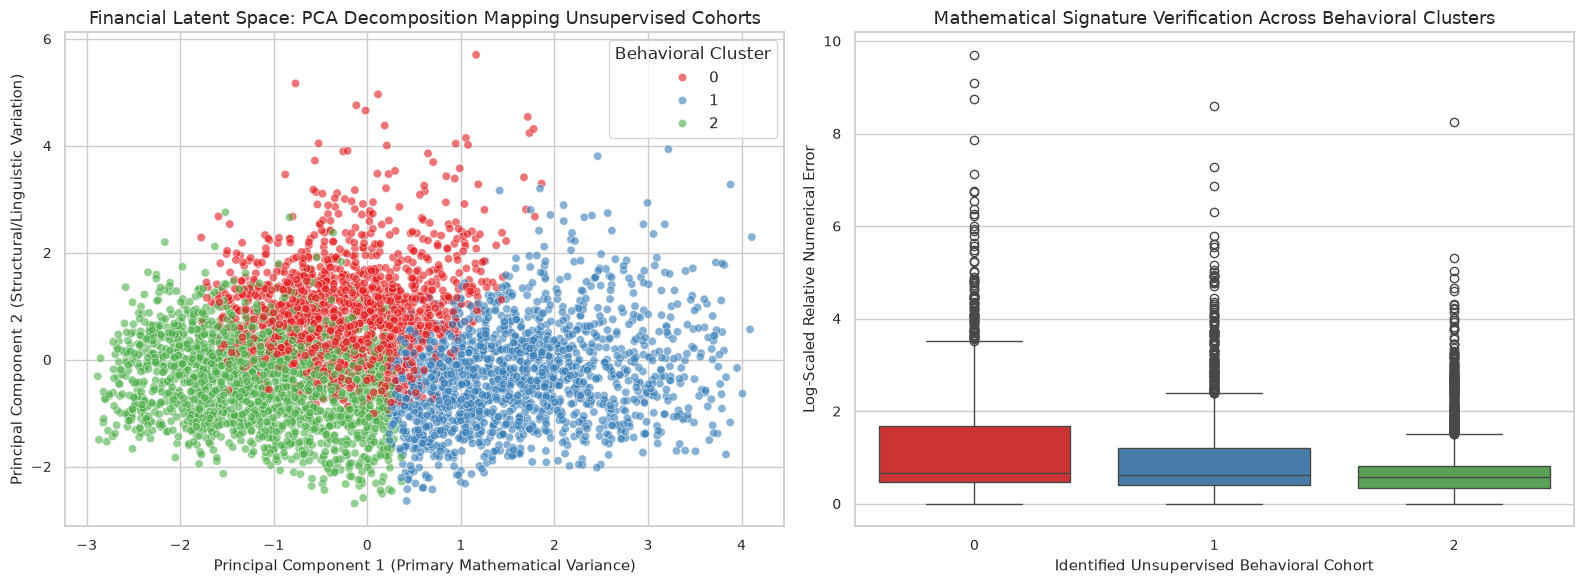

In [13]:
# ==========================================
# 4. EXECUTION ENVIROMENT
# ==========================================

if __name__ == "__main__":
    # Generate structured mock dataframe replicating the pipeline from part 1
    np.random.seed(42)
    N_records = 5000
    
    # Generating pipeline variables
    mock_pipeline_data = pd.DataFrame({
        'extracted_metric': np.random.exponential(scale=3000, size=N_records),
        'actual_metric': np.random.exponential(scale=3000, size=N_records),
        'linguistic_confidence': np.random.uniform(0.5, 1.0, size=N_records),
        'table_proximity_score': np.random.uniform(5.0, 95.0, size=N_records),
        'text_complexity_score': np.random.uniform(7.0, 18.0, size=N_records),
        'target_label': np.random.choice([0, 1], size=N_records, p=[0.15, 0.85]) # 15% Error Baseline
    })
    
    # Model explicit behavioral profiles (Rounding vs. Severe Hallucinations)
    error_mask = mock_pipeline_data['target_label'] == 0
    num_errors = error_mask.sum()
    
    # Split errors into 70% subtle rounding anomalies and 30% complete metric fabrications
    subtle_idx, catastrophic_idx = train_test_split(
        mock_pipeline_data[error_mask].index, 
        test_size=0.30, 
        random_state=42
    )
    
    # Cohort 1: Minor rounding noise
    mock_pipeline_data.loc[subtle_idx, 'extracted_metric'] *= np.random.uniform(1.01, 1.05, size=len(subtle_idx))
    
    # Cohort 2: Catastrophic, confident hallucinations (Simulating severe failure)
    mock_pipeline_data.loc[catastrophic_idx, 'extracted_metric'] *= np.random.uniform(2.5, 6.0, size=len(catastrophic_idx))
    mock_pipeline_data.loc[catastrophic_idx, 'linguistic_confidence'] = np.random.uniform(0.92, 1.0, size=len(catastrophic_idx))
    mock_pipeline_data.loc[catastrophic_idx, 'table_proximity_score'] += 30.0 # Push away from table structures
    
    # Feature engineering layer
    eps = 1e-5
    mock_pipeline_data['numerical_delta_rel'] = np.abs(mock_pipeline_data['extracted_metric'] - mock_pipeline_data['actual_metric']) / (np.abs(mock_pipeline_data['actual_metric']) + eps)
    mock_pipeline_data['log_numerical_delta_rel'] = np.log1p(mock_pipeline_data['numerical_delta_rel'])
    mock_pipeline_data['confidence_complexity_ratio'] = mock_pipeline_data['linguistic_confidence'] / (mock_pipeline_data['text_complexity_score'] + eps)
    
    # Delineating features to cluster over
    target_features = ['log_numerical_delta_rel', 'linguistic_confidence', 'table_proximity_score', 'text_complexity_score', 'confidence_complexity_ratio']
    
    # Run pipelines
    clustered_dataset, fitted_pca, fitted_kmeans = run_unsupervised_pipeline(
        mock_pipeline_data, 
        target_features, 
        n_clusters=3
    )
    
    profiles_matrix = profile_behavioral_clusters(clustered_dataset, target_features)
    generate_clustering_dashboards(clustered_dataset, profiles_matrix)